
#  Data exploration
Looks at the data before any modelling: label balance per source, email lengths, sample emails, and two leakage checks (give-away words, and a probe that tries to guess the source from the text).

Key result: a simple model could guess the source 87.8% of the time (chance = 12.5%), so the datasets are easy to tell apart. Tables and figures are saved to `Data/` for Chapter 4.
*






In [2]:
# Connect to Google Drive and load the two files from 01_data_download.ipynb

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt     # matplotlib draws charts



folder = "/content/drive/MyDrive/Colab Notebooks/Master's project/Data"

combined = pd.read_csv(os.path.join(folder, "phishing_combined.csv"))
education = pd.read_csv(os.path.join(folder, "phishing_education.csv"))
general = pd.read_csv(os.path.join(folder, "phishing_general.csv"))

print("Combined rows:", len(combined))
print("General rows:", len(general))
print("Education rows:", len(education))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Combined rows: 105353
General rows: 92397
Education rows: 16942


In [ ]:
# How many phishing vs legitimate emails in each source?
# This table matters a lot. If one source is ALL phishing and another is ALL legitimate, a model could learn "this looks like it came from Enron, so it's legitimate" instead of learning real phishing signs. That is data leakage.

table = pd.crosstab(combined["source"], combined["label"])   # rows = source, columns = label
table.columns = ["legitimate (0)", "phishing (1)"]
table["total"] = table.sum(axis=1)
table["% phishing"] = (table["phishing (1)"] / table["total"] * 100).round(1)
print(table)

# Save the table so I can paste it into the dissertation
table.to_csv(os.path.join(folder, "table_label_by_source.csv"))

                    legitimate (0)  phishing (1)  total  % phishing
source                                                             
CEAS_08                      17312         21833  39145        55.8
Enron                        15791         13954  29745        46.9
Ling                          2401           458   2859        16.0
Nazario                          0          1564   1564       100.0
Nigerian_Fraud                   0          3319   3319       100.0
SpamAssasin                   4091          1718   5809        29.6
eduphish                      6945          6011  12956        46.4
kuladeep_synthetic            3956          6000   9956        60.3


count     105353.0
mean        1872.0
std        20724.0
min            3.0
25%          293.0
50%          749.0
75%         2018.0
max      4600488.0
Name: length, dtype: float64

Average length by source:
source
CEAS_08                598.0
Enron                  741.0
Ling                  2055.0
Nazario                766.0
Nigerian_Fraud        2566.0
SpamAssasin           1123.0
eduphish              1987.0
kuladeep_synthetic     235.0
Name: length, dtype: float64


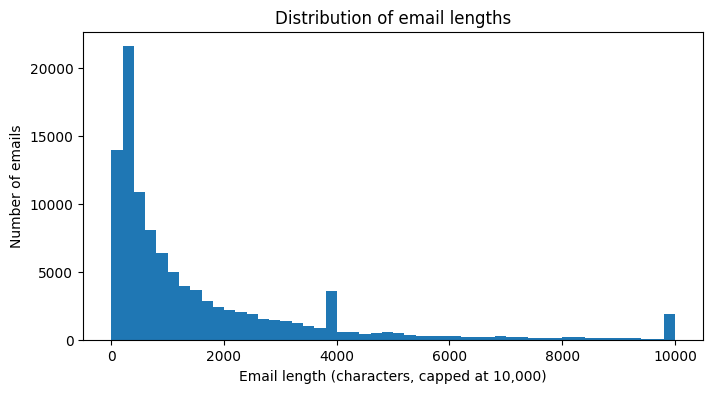


Emails longer than 5,000 characters: 6616
Emails shorter than 20 characters: 10


In [ ]:
# How long are the emails?
# Very long emails slow training down and are often junk (forwarded chains,  HTML code). Very short ones may have no useful content. This helps me decide on a sensible "length cap" for the cleaning notebook.

combined["length"] = combined["text"].str.len()      # number of characters in each email

print(combined["length"].describe().round(0))         # count, mean, min, max, and the quartiles

print("\nAverage length by source:")
print(combined.groupby("source")["length"].median().round(0))

# Draw a histogram (a bar chart of how many emails fall in each length range).
# I cut it off at 10,000 characters so the chart is readable.
plt.figure(figsize=(8, 4))
plt.hist(combined["length"].clip(upper=10000), bins=50)
plt.xlabel("Email length (characters, capped at 10,000)")
plt.ylabel("Number of emails")
plt.title("Distribution of email lengths")
plt.savefig(os.path.join(folder, "fig_email_lengths.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nEmails longer than 5,000 characters:", (combined["length"] > 5000).sum())
print("Emails shorter than 20 characters:", (combined["length"] < 20).sum())


In [ ]:
# Read a few real examples
# Numbers only tell part of the story. Reading actual emails shows me what kind of language, formatting and clutter is in there.
# I print 3 phishing and 3 legitimate emails from each source (cut to 500 characters).

for source in combined["source"].unique():
    print("\n" + "=" * 70)
    print("SOURCE:", source)
    for label, name in [(1, "PHISHING"), (0, "LEGITIMATE")]:
        sample = combined[(combined["source"] == source) & (combined["label"] == label)]
        if len(sample) == 0:
            print(f"\n  (no {name} emails in this source)")
            continue
        print(f"\n  --- {name} examples ---")
        for text in sample["text"].sample(min(3, len(sample)), random_state=1):
            print("  *", text[:500].replace("\n", " "), "\n")


SOURCE: SpamAssasin

  --- PHISHING examples ---
  * Norton Systemworks 2002 Pro Edition               12399      **Norton SystemWorks 2002   Software Suite   Professional Edition      ****6 Feature-Packed Utilities, 1 Great Price   A $300.00+ Combined Retail Value for  Only $29.99!      Protect your computer and your valuable information!      Don't allow yourself to fall prey to destructive viruses!      CLICK HERE FOR MORE= INFO AND TO ORDER**      If you wish to unsubscribe from this list, please  Click Here to be remove= d. 

  * Tired Of Your High Mortgage Rate - REFINANCE TODAY.... Dear Homeowner,   Interest Rates are at their lowest point in 40 years! We help you find the  best rate for your situation by matching your needs with hundreds of  lenders!  Home Improvement, Refinance, Second Mortgage,  Home Equity Loans, and much, much more!   You're eligible even with less than perfect credit!   This service is 100% FREE to home owners and new home buyers  without any obligation. 

In [ ]:
# Leakage check - which words are unusually common in ONE source?
# If a word like "enron" or "spamassassin" appears in nearly every email from one source and nowhere else, the model can use it as a shortcut.
# This cell finds the most "give-away" words for each source.

# How it works, in plain terms:
#   1. Count how many emails each word appears in (once per email, not total).
#   2. For each source, find words that appear in a high share of ITS emails but a low share of everyone else's.

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Turn the emails into a big table of "does this word appear in this email" (1 or 0).
# min_df=50 means: ignore rare words that appear in fewer than 50 emails.
vec = CountVectorizer(binary=True, min_df=50, stop_words="english", max_features=20000)
X = vec.fit_transform(combined["text"])
words = np.array(vec.get_feature_names_out())

for source in combined["source"].unique():
    in_source = (combined["source"] == source).values
    share_inside = np.asarray(X[in_source].mean(axis=0)).ravel()      # % of this source's emails containing the word
    share_outside = np.asarray(X[~in_source].mean(axis=0)).ravel()    # % of all OTHER emails containing the word
    giveaway = share_inside - share_outside                          # big number = strong give-away
    top = np.argsort(giveaway)[::-1][:15]                             # the 15 biggest
    print(f"\n{source}: words that give this source away")
    for i in top:
        print(f"   {words[i]:<20} in {share_inside[i]*100:5.1f}% of {source} emails,"
              f" {share_outside[i]*100:5.1f}% elsewhere")


SpamAssasin: words that give this source away
   2002                 in  41.5% of SpamAssasin emails,   2.5% elsewhere
   listinfo             in  43.2% of SpamAssasin emails,   6.4% elsewhere
   http                 in  74.3% of SpamAssasin emails,  39.4% elsewhere
   list                 in  48.6% of SpamAssasin emails,  14.0% elsewhere
   www                  in  50.7% of SpamAssasin emails,  19.2% elsewhere
   mailman              in  32.8% of SpamAssasin emails,   6.3% elsewhere
   net                  in  32.4% of SpamAssasin emails,   7.9% elsewhere
   mailing              in  31.0% of SpamAssasin emails,   8.2% elsewhere
   com                  in  63.6% of SpamAssasin emails,  42.4% elsewhere
   lists                in  20.8% of SpamAssasin emails,   2.2% elsewhere
   _______________________________________________ in  22.7% of SpamAssasin emails,   4.8% elsewhere
   users                in  21.4% of SpamAssasin emails,   3.7% elsewhere
   just                 in  32.7% of S

In [ ]:
# Leakage check - can a model guess the SOURCE from the text?
# This is the strongest test. I train a very quick model to predict which dataset an email came from. If it does this easily (say, over 90% right), then source-specific clues are baked into the text and I must clean them out.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split emails into 80% for training and 20% for testing the guess
train_text, test_text, train_src, test_src = train_test_split(
    combined["text"], combined["source"], test_size=0.2, random_state=42, stratify=combined["source"])

tfidf = TfidfVectorizer(max_features=20000, stop_words="english")
model = LogisticRegression(max_iter=1000)
model.fit(tfidf.fit_transform(train_text), train_src)

accuracy = model.score(tfidf.transform(test_text), test_src)
print(f"A quick model can guess the SOURCE of an email {accuracy*100:.1f}% of the time.")
print("(Pure guessing would score about", round(100 / combined['source'].nunique(), 1), "%)")
print("\nIf this number is very high, the sources are easy to tell apart and")
print("I need to remove source-identifying clues in the cleaning notebook.")


A quick model can guess the SOURCE of an email 87.8% of the time.
(Pure guessing would score about 12.5 %)

If this number is very high, the sources are easy to tell apart and
I need to remove source-identifying clues in the cleaning notebook.


In [ ]:
# Now let me take first look at the education data on its own

print("Education label balance (0 = legitimate, 1 = phishing):")
print(education["label"].value_counts())

education["length"] = education["text"].str.len()
print("\nEducation email lengths:")
print(education["length"].describe().round(0))

print("\n3 example education phishing emails:")
for text in education[education["label"] == 1]["text"].sample(3, random_state=1):
    print("  *", text[:500].replace("\n", " "), "\n")

Education label balance (0 = legitimate, 1 = phishing):
label
0    9125
1    7817
Name: count, dtype: int64

Education email lengths:
count      16942.0
mean        3536.0
std        36570.0
min           43.0
25%          953.0
50%         1948.0
75%         3798.0
max      4600488.0
Name: length, dtype: float64

3 example education phishing emails:
  * from the desk of hajia mariam abacha ( mrs ) dear friend , this might be a surprise to you about where i got your contact address . please i got your name and address through a commercial publication via internet courtesy of s . a . i . e . during my desperate search for someone that could honestly and confidentially assist me by serving as my trustee . i am mrs . mariam abacha , the widow of the late gen . sanni abacha former nigerian military head of state who died mysteriously as a result of  

  * FROM:MR MOHAMED MANGUAsalam Aleykom, This message might meet you in utmost surprise however,it's just my urgent need for a foreign partn

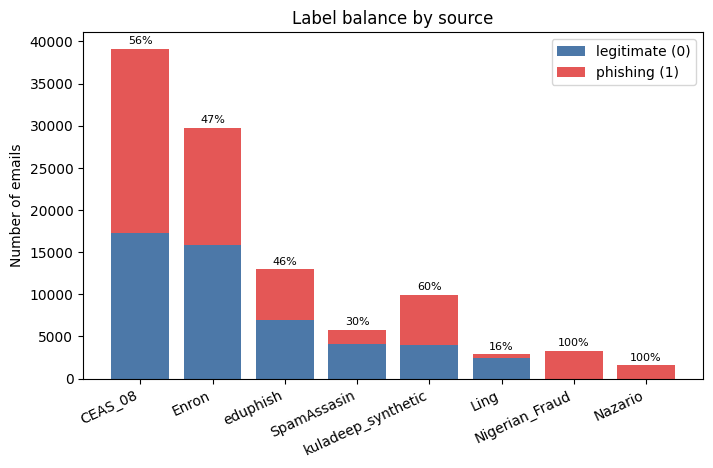

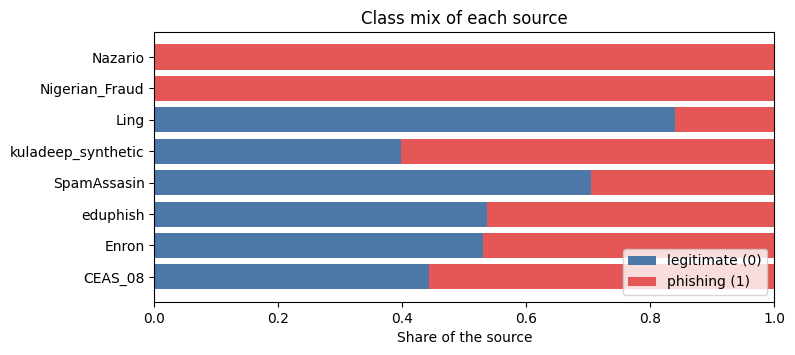

Saved both charts to the Results folder.

label                   0      1
source                          
CEAS_08             17312  21833
Enron               15791  13954
eduphish             6945   6011
SpamAssasin          4091   1718
kuladeep_synthetic   3956   6000
Ling                 2401    458
Nigerian_Fraud          0   3319
Nazario                 0   1564


In [3]:
# A stacked barchart
# Cell 2 printed this as a table. This cell draws it, which makes the problem much easier to see. Each bar is one source, split into two colours:
# blue for legitimate emails and red for phishing ones.

# What to look for: a bar that is ALL ONE COLOUR. If a source contains only phishing, then a model that learns to recognise that source gets the answe for free, without understanding anything about phishing.
# That is the leakage problem this project is about, and Cell 6 measured it as a number.

import numpy as np

# Figures for the write-up are saved in the Results folder
results_folder = "/content/drive/MyDrive/Colab Notebooks/Master's project/Results"
os.makedirs(results_folder, exist_ok=True)

# Count the legitimate (0) and phishing (1) emails in each source
counts = combined.groupby(["source", "label"]).size().unstack(fill_value=0)
counts = counts.sort_values(by=list(counts.columns), ascending=False)

sources = counts.index.tolist()
legit = counts[0].values if 0 in counts.columns else np.zeros(len(sources))
phish = counts[1].values if 1 in counts.columns else np.zeros(len(sources))
totals = legit + phish

# Chart 1: how many emails, stacked by label
plt.figure(figsize=(8, 4.5))
plt.bar(sources, legit, label="legitimate (0)", color="#4C78A8")
plt.bar(sources, phish, bottom=legit, label="phishing (1)", color="#E45756")

# print the phishing percentage above each bar
for i in range(len(sources)):
    if totals[i] > 0:
        plt.text(i, totals[i] + max(totals) * 0.015,
                 f"{phish[i] / totals[i] * 100:.0f}%", ha="center", fontsize=8)

plt.ylabel("Number of emails")
plt.title("Label balance by source")
plt.legend()
plt.xticks(rotation=25, ha="right")
plt.savefig(os.path.join(results_folder, "fig_label_balance_by_source.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Chart 2: the same thing as percentages
# Sizes differ a lot between sources, so this second chart ignores size and shows only the mix. Sources that are entirely one colour stand out here.

plt.figure(figsize=(8, 3.5))
plt.barh(sources, legit / totals, label="legitimate (0)", color="#4C78A8")
plt.barh(sources, phish / totals, left=legit / totals,
         label="phishing (1)", color="#E45756")
plt.xlim(0, 1)
plt.xlabel("Share of the source")
plt.title("Class mix of each source")
plt.legend(loc="lower right")
plt.savefig(os.path.join(results_folder, "fig_label_share_by_source.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("Saved both charts to the Results folder.\n")
print(counts)
